### 기초

1. 시계열 분해 / EDA 진행 
    - STL 분해 = 추세, 계절성, 잔차 분리

2. station 확인 
    - KPSS, ADF 사용
    - 정상성을 만족하지 않는다면 조치
        - 분산이 일정하지 않다면 box-cox, log변환 (먼저)
            - 차분 후에는 음수가 생길 수 있어 분산 안정화 기법을 적용할 수 없음
        - 평균이 일정하지 않다면 차분, 로그차분

3. 모형 선정
    - 기본 ARIMA
    - 계절성이 있다면 SARIMA

4. 모형 fit
    - ACF/PACF 상황에 따라 모형 detail 선정
        - ACF가 절단이면 MA
        - PACF가 절단이면 AR
    - AutoARIMA 등의 알고리즘 사용
    
5. 생성된 모형 타당성 검정
    - Ljung-Box 검정


#### 

### 시계열 분해

원데이터를 추세(Trend), 계절성(Seasonality), 불규칙/잔차(Irregular/Residual) 성분으로 분리
데이터의 구조적 특성을 직관적으로 파악 (정상성 등)

- 추세: 데이터의 이동평균 또는 경향성, 장기간에 걸쳐서 나타남
- 계절성: 데이터에의 반복적, 규칙적 변동    
    - 순환변동 (Cyclical Component): 장기간에 걸친 경제적 / 기타 사이클로 인한 변동 (계절성보다 긴 기간에 걸쳐 발생)
- 잔차: 불규칙한 변동, 노이즈 (모델로 설명되지 않음)

,추세,계절성,잔차,원본 시계열 데이터
date,,,,
1959-01-01,NaN,-4.706352,NaN,2710.349
1959-04-01,NaN,4.237946,NaN,2778.801
1959-07-01,2779.62925,2.828948,-6.970198,2775.488


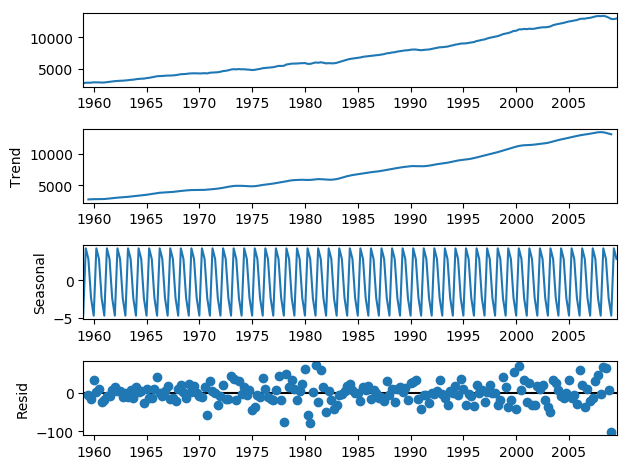

In [ ]:
import statsmodels.api as sm
data_ts = sm.datasets.macrodata.load_pandas().data
# from statsmodels.tsa.seasonal import seasonal_decompose

import numpy as np; import pandas as pd; import matplotlib.pyplot as plt
# import warnings; warnings.filterwarnings('ignore')

# time = pd.date_range('2020-01-01', periods=100, freq='D')
# data = np.random.randn(100).cumsum() + 10 * np.sin(np.linspace(0, 10, 100))

data_ts = data_ts[['year', 'quarter', 'realgdp']]
data_ts['date'] = pd.to_datetime(data_ts['year'].astype(str).str[:4] + 'Q' + data_ts['quarter'].astype(str).str[:1])


# 시계열 분해
series = data_ts[['date', 'realgdp']].set_index('date')
result = sm.tsa.seasonal_decompose(series, model='additive', period=4)  # model='multiplicative' 구성요소들이 곱셈으로 연결됨을 가정

display(pd.DataFrame([result.trend, result.seasonal, result.resid, result.observed], index=['추세', '계절성', '잔차', '원본 시계열 데이터']).T.head(3))

# 분해 결과 시각화
result.plot() # 원본데이터, 추세, 계절, 잔차에 대한 정보
plt.show()


# # 2. 첫 번째 축에 결과 시각화
# fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# result.plot(ax=axes[0])
# axes[0].set_title("Decomposition Results")
# plt.tight_layout()
# plt.show()



### 정상성

시계열 데이터의 동계적 특성이 시간에 따라 일정하게 유지되는 성질     

- 모든 시간 t에 평균이 상수다.      
- 모든 시간 t에 분산이 상수다.     
- 모든 시간 t와 시차 k 에 대해, 공분산은 k에만 의존하고 t에는 의존하지 않는다.    

위의 조건을 만족하면 정상성을 가진다.

#### 정상성 검정

체크하는 대상은 동일하지만, 검정방향이 정반대

- Augmented Dickey-Fuller (ADF) 검정
    - 단위근 존재 여부를 체크한다.
    - 단위근이 존재한다면 비정상 시계열이다.
    - 단위근이 존재한다 = 과거의 충격이 사라지지 않고 미래에 계속 영향을 주고 있다.
- Kwiatkowski-Phillips-Schmidt-Shin (KPSS) 검정
    - 정상성 여부를 체크한다.

<br>

| 비교 항목 | ADF 검정 (Augmented Dickey-Fuller, 단위근 검정) | KPSS 검정 (Kwiatkowski-Phillips-Schmidt-Shin, 정상성 검정) |
| :--- | :--- | :--- |
| **귀무가설 ($H_0$)** | 데이터에 단위근이 존재한다. (비정상 시계열) | 데이터가 정상성을 만족한다. (정상 시계열) |
| **대립가설 ($H_1$)** | 데이터가 정상성을 만족한다. (정상 시계열) | 데이터에 단위근이 존재한다. (비정상 시계열) |
| **검정 목적** | 확률적 추세 **(단위근) 존재 여부** 확인 | 결정론적 추세 주변의 **정상성 여부** 확인 |
| **p-value < 0.05 해석** | **정상 시계열**로 판단 (귀무가설 기각) | **비정상 시계열**로 판단 (귀무가설 기각) |
| **p-value > 0.05 해석** | **비정상 시계열**로 판단 (귀무가설 채택) | **정상 시계열**로 판단 (귀무가설 채택) |
| **파이썬 라이브러리** | `statsmodels.tsa.stattools.adfuller` | `statsmodels.tsa.stattools.kpss` |

<br>
<br>





| Case | ADF 검정 (단위근 존재 여부) | KPSS 검정 (정상성 여부) | 시계열의 상태 (판별 결과) | 정상성 확보를 위한 조치 |
| :--- | :--- | :--- | :--- | :--- |
| **Case 1** | 기각 (p < 0.05) : 정상 | 채택 (p > 0.05) : 정상 | **엄격한 정상 시계열** (Strictly Stationary) | 변환 불필요. 즉시 모델 적합 진행 |
| **Case 2** | 채택 (p > 0.05) : 비정상 | 기각 (p < 0.05) : 비정상 | **차분 정상 시계열** (Difference Stationary) | 1차 또는 2차 **차분(Differencing)** 수행 |
| **Case 3** | 채택 (p > 0.05) : 비정상 | 채택 (p > 0.05) : 정상 | **추세 정상 시계열** (Trend Stationary) | 결정론적 **추세 제거(Detrending)** 수행 |
| **Case 4** | 기각 (p < 0.05) : 정상 | 기각 (p < 0.05) : 비정상 | **구조적 변화/분산 불안정** (Structural break 등) | 구조적 변화 탐지 또는 **분산 안정화(Log)** 후 차분 |

In [ ]:
# 정상성 검정

import pandas as pd

import statsmodels.api as sm
data_ts = sm.datasets.macrodata.load_pandas().data

# from statsmodels.tsa.stattools import adfuller, kpss

result = sm.tsa.adfuller(data_ts['realgdp'])

display(pd.DataFrame(
    (result[0], result[1], result[2], result[3], result[4], result[5], ('H_0 기각, 정상' if result[1] < 0.05 else 'H_0 채택, 비정상') + ' - 정상 시계열 여부')
    , index=['ADF Statistic', 'p-value', '#Lags Used', 'Number of Observations Used', 'Critical Values', 'IC Best', '정상성 여부']
))


,0
ADF Statistic,1.75046
p-value,0.998246
#Lags Used,12
Number of Observations Used,190
Critical Values,"{'1%': -3.4652439354133255, '5%': -2.876875228..."
IC Best,2034.52
정상성 여부,"H_0 채택, 비정상 - 정상 시계열 여부"


#### ACF-PACF

- ACF 자기상관함수 : 정상시계열이면 빠르게 0 으로 수렴해야함    
- PACF : 부분자기 상관함수

그래프 그렸을 때 파란 영역(신뢰구간,95%) 내에 들어오는 x축의 값을 차수로 차용        

```python
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # ACF : ma 모형 차수 결정(q) 및 PACF : ar 모형 차수 결정(p)
```

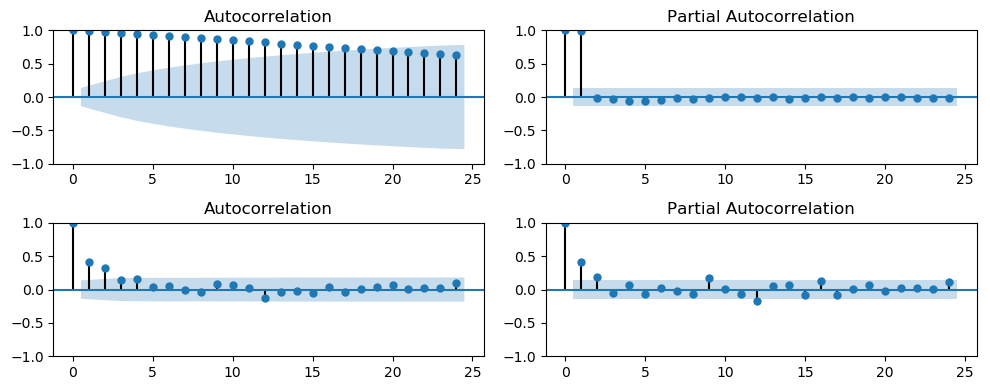

In [15]:
# 정상성 검정

import statsmodels.api as sm
import statsmodels.tsa.api as tsa
data_ts = sm.datasets.macrodata.load_pandas().data
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import numpy as np; import pandas as pd; import matplotlib.pyplot as plt
# import warnings; warnings.filterwarnings('ignore')

# acf와 pacf의 값을 원본데이터와 1차 차분 결과로 구분해서 확인

series = data_ts['realgdp']

plt.close('all')
fig, ax = plt.subplots(2,2,figsize=(10,4))

if True:
    ax[0,0].set_title('raw data - acf');        tsa.graphics.plot_acf(series,ax= ax[0,0])
    ax[0,1].set_title('raw data - pacf');       tsa.graphics.plot_pacf(series,ax= ax[0,1])
    ax[1,0].set_title('diff(1) data - acf');    tsa.graphics.plot_acf(series.diff(1).dropna(),ax= ax[1,0])
    ax[1,1].set_title('diff(1) data - pacf');   tsa.graphics.plot_pacf(series.diff(1).dropna(),ax= ax[1,1])

fig.tight_layout()
plt.show()

### ARIMA, SARIMA

자기회귀(AR), 차분(Integrated), 이동평균(MA)을 포함하는 시계열 모델     
ARIMA(p,d,q)로 표현 된다. p는 자기회귀 부분의 차수, d는 차분의 차수, q는 이동평균 부분의 차수

ARIMA 모델에 계절성(seasonal) 요소가 추가된 모델 (SARIMA)
```python
```

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            realgdp   No. Observations:                  203
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1042.403
Date:                            Fri, 06 Mar 2026   AIC                           2094.806
Time:                                    01:10:14   BIC                           2111.041
Sample:                                01-01-1959   HQIC                          2101.382
                                     - 07-01-2009                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7073      0.108      6.576      0.000       0.497       0.918
ma.L1         -0.3406      0.141     -2.408      0.016      -0.618      -0.063
ar.S.L12      -0.2569      0.083     -3.089      0.002      -0.420      -0.094
ma.S.L12      -0.8282      0.065    -12.729      0.000      -0.956      -0.701
sigma2      3078.8350    274.289     11.225      0.000    2541.239    3616.431
===================================================================================
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):                11.44
Prob(Q):                              0.68   Prob(JB):                         0.00
Heteroskedasticity (H):               2.68   Skew:                            -0.21
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

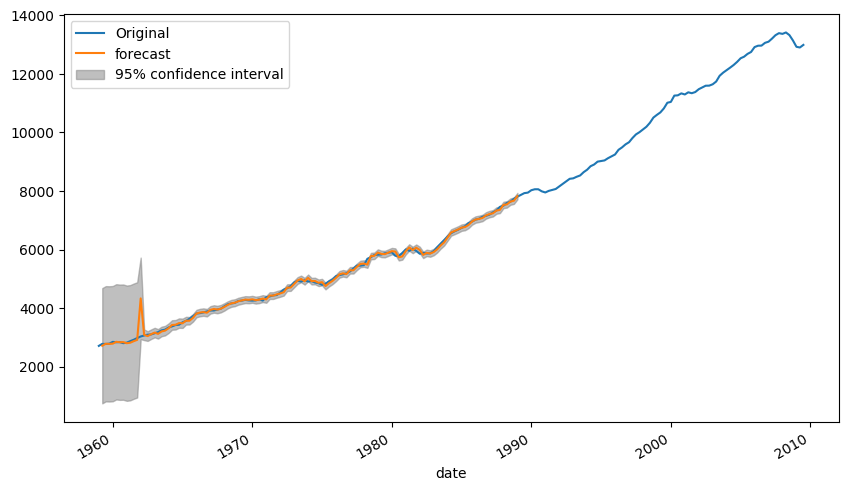

In [ ]:
# 정상성 검정

import statsmodels.api as sm; import statsmodels.tsa.api as tsa
data_ts = sm.datasets.macrodata.load_pandas().data
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import numpy as np; import pandas as pd; import matplotlib.pyplot as plt
# import warnings; warnings.filterwarnings('ignore')

# from statsmodels.tsa.arima.model import ARIMA
# from statsmodels.graphics.tsaplots import plot_predict
# from statsmodels.tsa.statespace.sarimax import SARIMAX

data_ts['date'] = pd.to_datetime(data_ts['year'].astype(str).str[:4] + 'Q' + data_ts['quarter'].astype(str).str[:1])
series = data_ts[['date', 'realgdp']].set_index('date')

# 모델 적합을 수행하기 전에 인덱스 주기 명시적 할당
series.index.freq = 'QS-OCT' 

# 만약 데이터 중간에 이빨이 빠진(결측) 구간이 있다면 asfreq를 사용하여 빈 공간을 채워야 함
# series = series.asfreq('QS-OCT')

# 비계절성 패러미터. ARIMA / SARIMA 모델의 차수 설정
# 실제 데이터에 따라 p, d, q 값을 조정한다.
# p-plot_acf로 확인, q-plot_pacf, d-차분 그래프

p, d, q = 2, 1, 2

# 계절성 패러미터. SARIMA 모델의 계절성 설정
# P, D, Q는 계절성 자기회귀, 계절성 차분, 계절성 이동평균 요소의 차수를 나타내며, S는 계절 주기를 나타냅니다.
# S는 몇개월 주기의 데이터인지 확인 후 해당 개월수를 넣는다.

P, D, Q, S = 1, 1, 1, 12

if 'ARIMA':
    model = tsa.arima.ARIMA(series, order=(p, d, q))
    model_fit = model.fit()

if 'SARIMA':
    model = tsa.statespace.SARIMAX(series, order=(p, d, q), seasonal_order=(P, D, Q, S)) 
    model_fit = model.fit(disp=False)


# 모델 요약 정보 출력
display(model_fit.summary())

# 예측 결과 시각화
plt.figure(figsize=(10, 6))
if True:
    plt.plot(series, label='Original')
    tsa.graphics.plot_predict(model_fit, start=1, end=120, dynamic=False, plot_insample=False, ax=plt.gca())
    plt.legend()
plt.show()

# 미래 값 예측
forecast = model_fit.forecast(steps=100)  # 다음 100개 데이터 포인트 예측



,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19
